<a href="https://colab.research.google.com/github/lynchpo/DSE5002_Module2/blob/main/Capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# Exploratory Data Analysis
## Economic Forecasting for Banking Using FRED Time Series
##Project:** 30-Year Fixed Mortgage Rate Forecasting (Phase 1)
##Author:** Patrick Lynch | Dragon Exploder | Independent Study
##GitHub:** https://github.com/lynchpo/dragon_exploder_fred

In [8]:
import requests
from io import StringIO

series_urls = {
    'MORTGAGE30US': 'https://fred.stlouisfed.org/graph/fredgraph.csv?id=MORTGAGE30US',
    'DGS10':        'https://fred.stlouisfed.org/graph/fredgraph.csv?id=DGS10',
    'FEDFUNDS':     'https://fred.stlouisfed.org/graph/fredgraph.csv?id=FEDFUNDS',
    'UNRATE':       'https://fred.stlouisfed.org/graph/fredgraph.csv?id=UNRATE',
    'CPIAUCSL':     'https://fred.stlouisfed.org/graph/fredgraph.csv?id=CPIAUCSL',
    'HOUST':        'https://fred.stlouisfed.org/graph/fredgraph.csv?id=HOUST'
}

raw = {}
for name, url in series_urls.items():
    r = requests.get(url, timeout=20)
    r.raise_for_status()
    df = pd.read_csv(StringIO(r.text), parse_dates=['observation_date'])
    df = df.rename(columns={'observation_date': 'date', name: name})
    df = df.set_index('date').sort_index()
    raw[name] = df
    print(f"{name:12} | {len(df):5} rows | {df.index.min().date()} → {df.index.max().date()}")

MORTGAGE30US |  2888 rows | 1971-04-02 → 2026-07-30
DGS10        | 16848 rows | 1962-01-02 → 2026-07-30
FEDFUNDS     |   864 rows | 1954-07-01 → 2026-06-01
UNRATE       |   942 rows | 1948-01-01 → 2026-06-01
CPIAUCSL     |   954 rows | 1947-01-01 → 2026-06-01
HOUST        |   810 rows | 1959-01-01 → 2026-06-01


In [9]:
# Restrict to a common recent window for EDA

start_date = '2000-01-01'
aligned = {}

for name, df in raw.items():
    aligned[name] = df.loc[start_date:].copy()

# Quick look at missingness
print("Missing values after 2000-01-01:")
for name, df in aligned.items():
    missing = df[name].isna().sum()
    pct = missing / len(df) * 100
    print(f"  {name:12}: {missing:4} missing ({pct:5.1f}%)")

Missing values after 2000-01-01:
  MORTGAGE30US:    0 missing (  0.0%)
  DGS10       :  287 missing (  4.1%)
  FEDFUNDS    :    0 missing (  0.0%)
  UNRATE      :    1 missing (  0.3%)
  CPIAUCSL    :    1 missing (  0.3%)
  HOUST       :    0 missing (  0.0%)


In [10]:
# Combine into one DataFrame for convenience
df = pd.concat([aligned[s] for s in aligned], axis=1)

print("=== Descriptive Statistics (2000–present) ===\n")
desc = df.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T
desc['skew'] = df.skew()
desc['kurtosis'] = df.kurtosis()
display(desc[['count', 'mean', 'std', 'min', '5%', '25%', '50%', '75%', '95%', 'max', 'skew', 'kurtosis']])

=== Descriptive Statistics (2000–present) ===



,count,mean,std,min,5%,25%,50%,75%,95%,max,skew,kurtosis
MORTGAGE30US,1387.000,5.230,1.390,2.650,3.100,3.970,5.210,6.355,7.180,8.640,0.084,-1.054
DGS10,6647.000,3.344,1.290,0.520,1.450,2.260,3.480,4.320,5.230,6.790,0.009,-0.737
FEDFUNDS,318.000,2.039,2.025,0.050,0.080,0.150,1.320,3.925,5.330,6.540,0.676,-0.983
UNRATE,317.000,5.619,1.935,3.400,3.600,4.200,5.000,6.200,9.500,14.800,1.330,1.698
CPIAUCSL,317.000,235.018,42.894,169.300,177.120,202.000,231.893,256.036,319.105,333.979,0.559,-0.476
HOUST,318.000,1309.088,420.128,478.000,582.850,1037.500,1323.000,1600.000,2024.150,2273.000,-0.107,-0.606


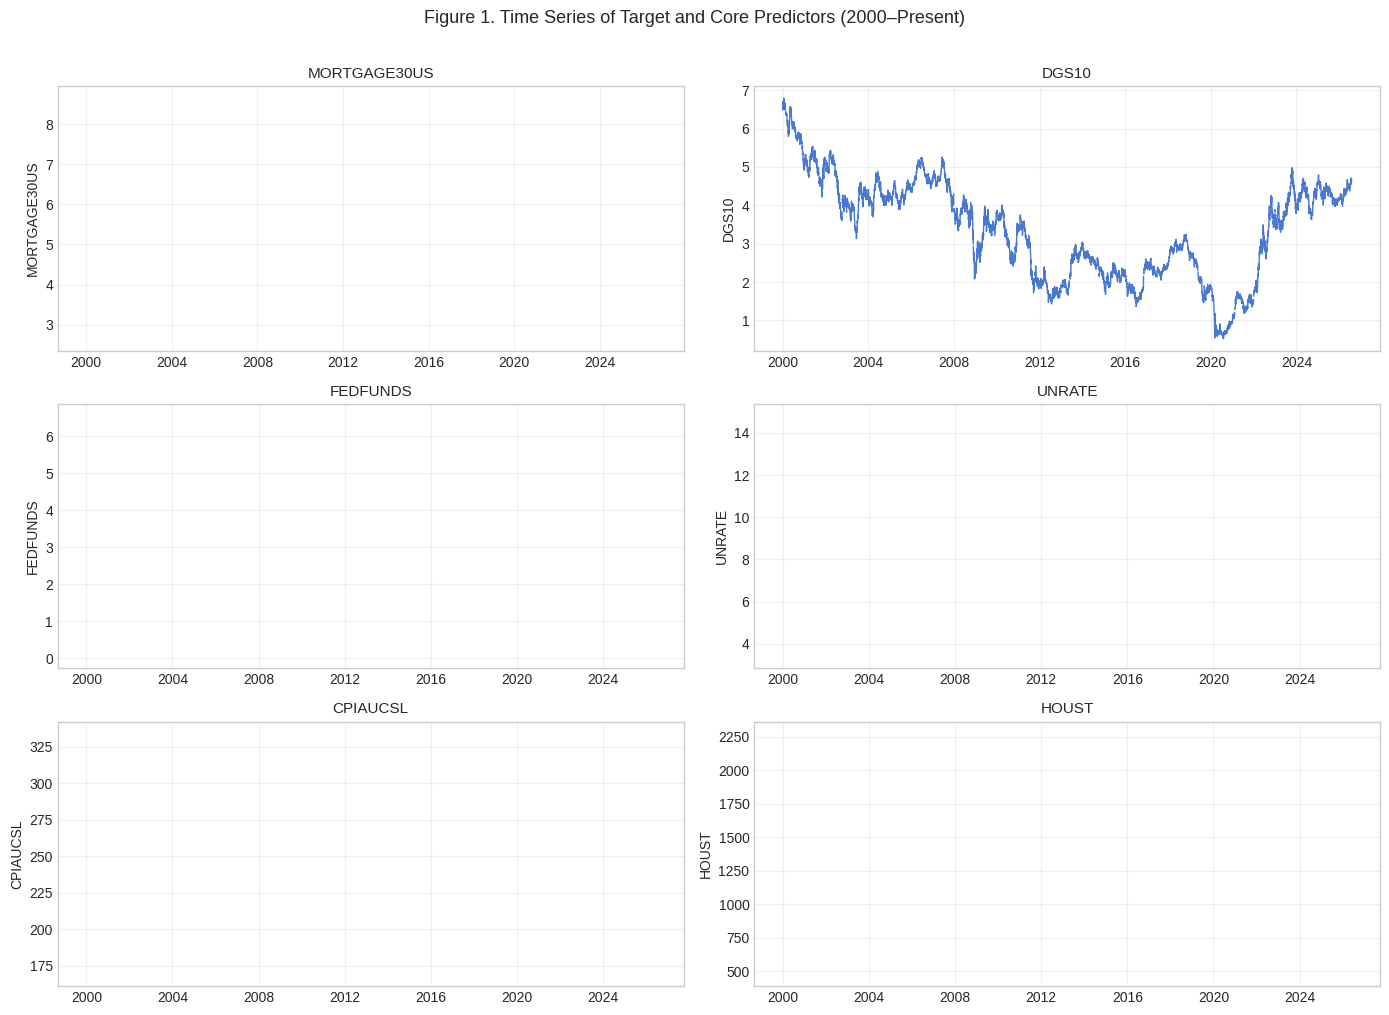

In [11]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=False)
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].plot(df.index, df[col], linewidth=1.0)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel(col)
    axes[i].grid(True, alpha=0.3)

plt.suptitle("Figure 1. Time Series of Target and Core Predictors (2000–Present)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

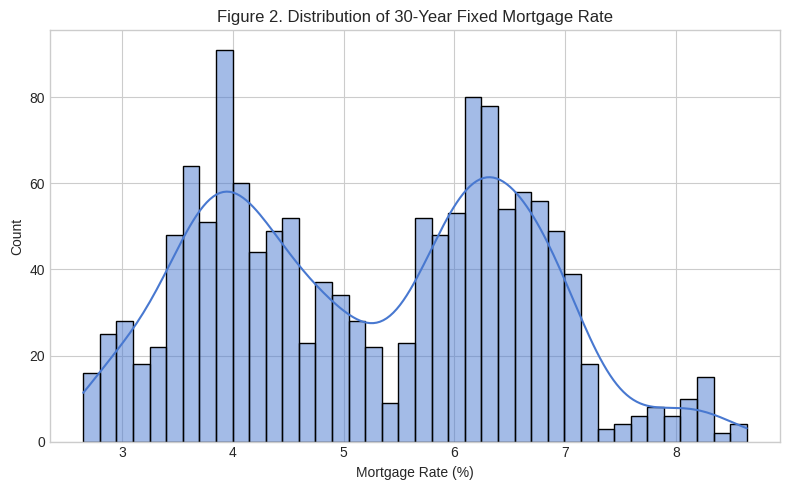

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df['MORTGAGE30US'].dropna(), bins=40, kde=True, ax=ax)
ax.set_title("Figure 2. Distribution of 30-Year Fixed Mortgage Rate")
ax.set_xlabel("Mortgage Rate (%)")
plt.tight_layout()
plt.show()

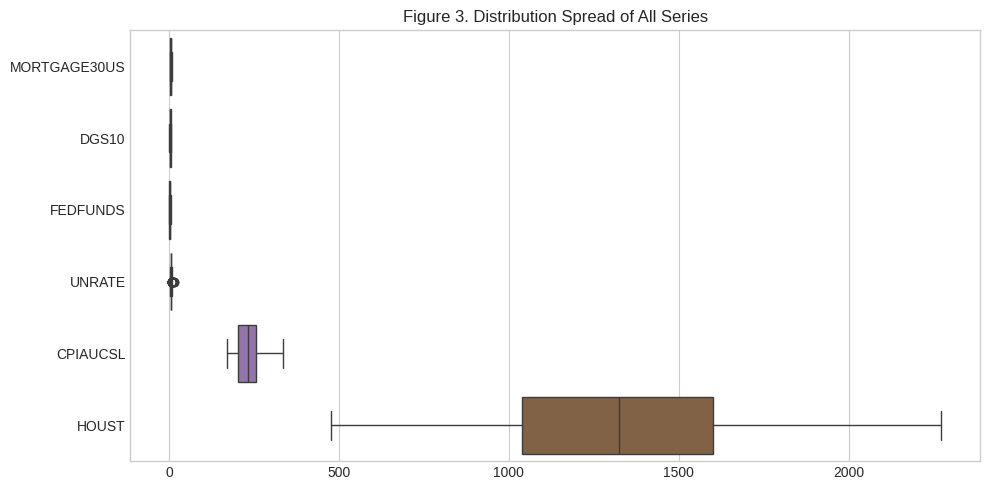

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, orient='h', ax=ax)
ax.set_title("Figure 3. Distribution Spread of All Series")
plt.tight_layout()
plt.show()

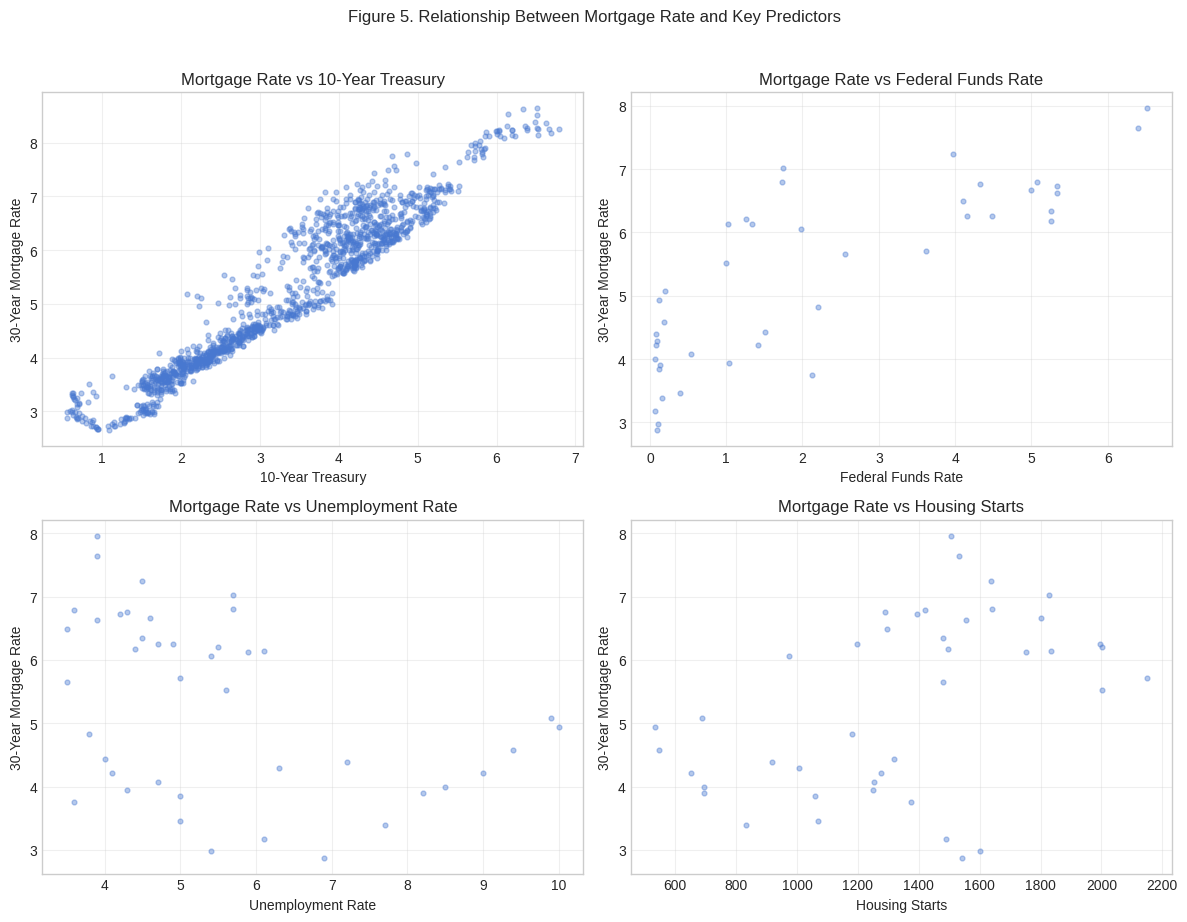

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
pairs = [('DGS10', '10-Year Treasury'),
         ('FEDFUNDS', 'Federal Funds Rate'),
         ('UNRATE', 'Unemployment Rate'),
         ('HOUST', 'Housing Starts')]

for ax, (col, label) in zip(axes.flatten(), pairs):
    ax.scatter(df[col], df['MORTGAGE30US'], alpha=0.4, s=12)
    ax.set_xlabel(label)
    ax.set_ylabel("30-Year Mortgage Rate")
    ax.set_title(f"Mortgage Rate vs {label}")
    ax.grid(True, alpha=0.3)

plt.suptitle("Figure 5. Relationship Between Mortgage Rate and Key Predictors", y=1.02)
plt.tight_layout()
plt.show()

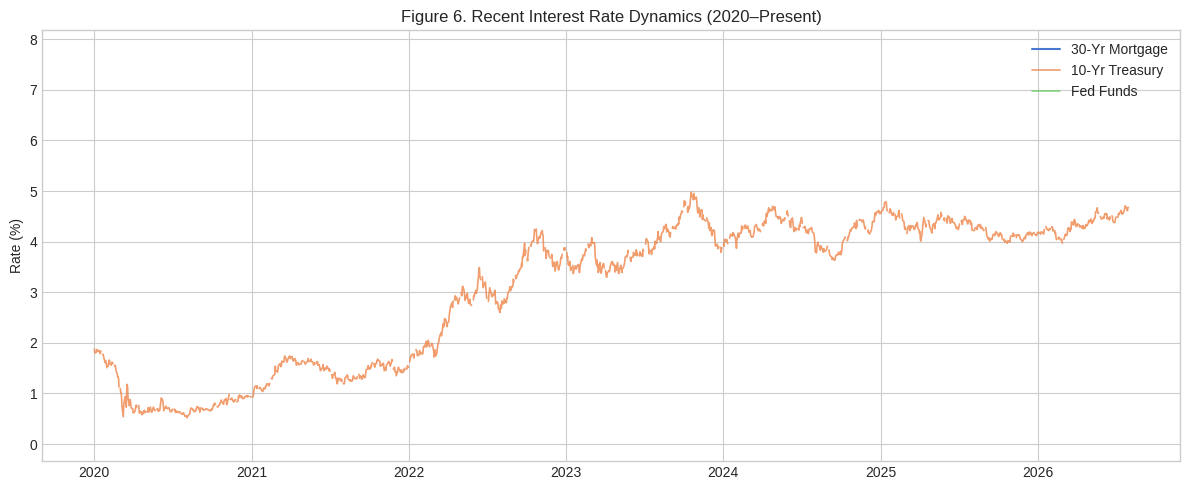

In [15]:
# Zoom into the 2020–2026 period to inspect recent dynamics
recent = df.loc['2020-01-01':]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(recent.index, recent['MORTGAGE30US'], label='30-Yr Mortgage', linewidth=1.5)
ax.plot(recent.index, recent['DGS10'], label='10-Yr Treasury', linewidth=1.2, alpha=0.8)
ax.plot(recent.index, recent['FEDFUNDS'], label='Fed Funds', linewidth=1.2, alpha=0.8)
ax.set_title("Figure 6. Recent Interest Rate Dynamics (2020–Present)")
ax.legend()
ax.set_ylabel("Rate (%)")
plt.tight_layout()
plt.show()

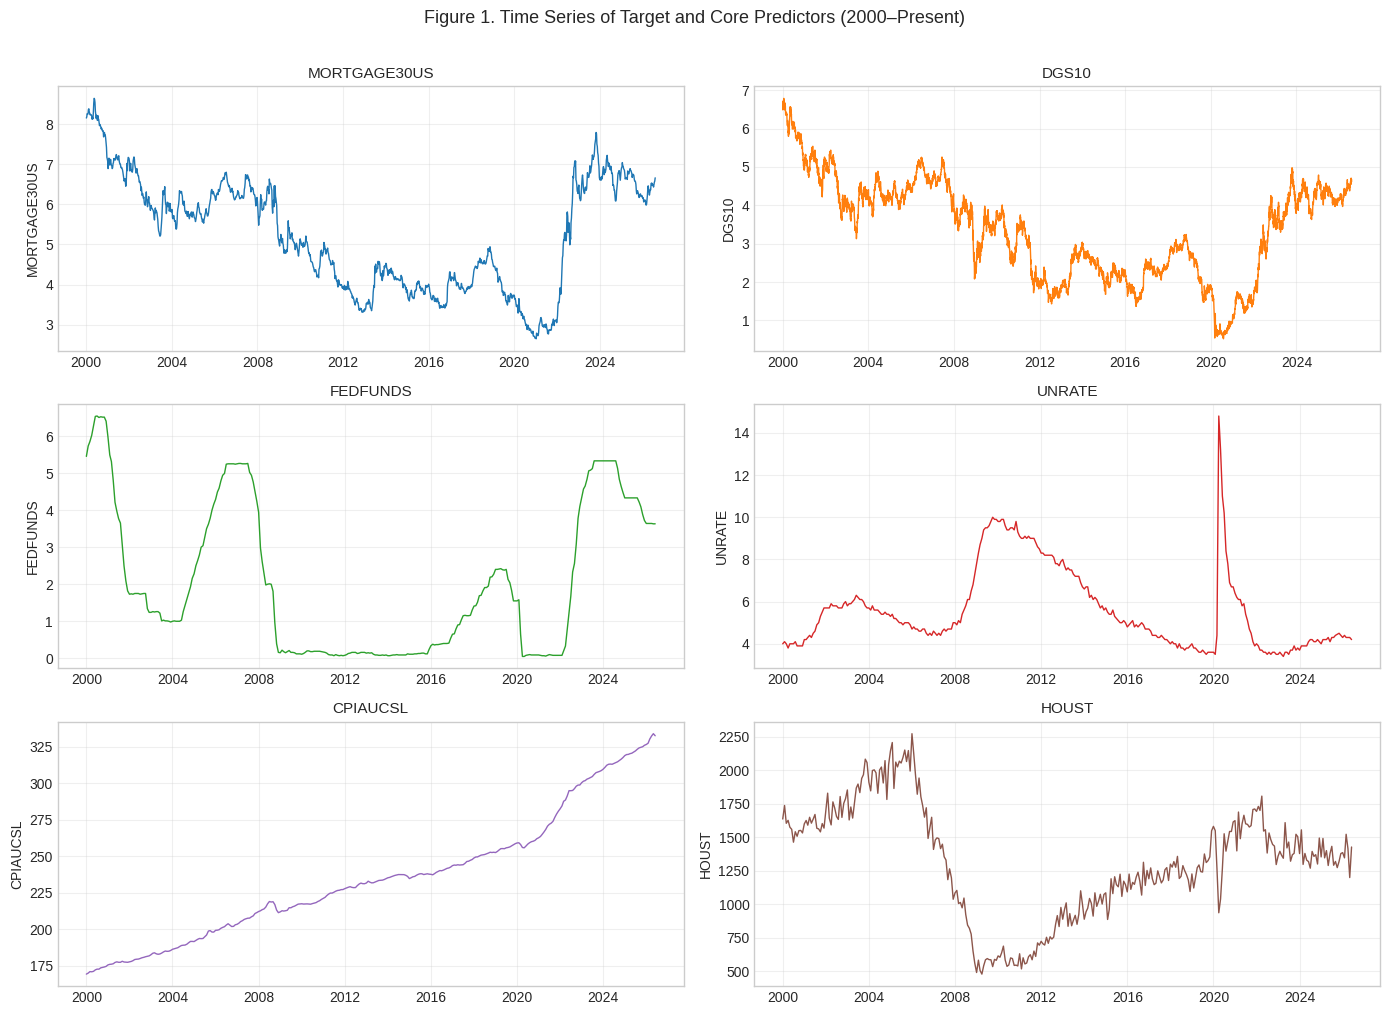

In [16]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for i, col in enumerate(df.columns):
    series = df[col].dropna()
    axes[i].plot(series.index, series.values, color=colors[i], linewidth=1.0)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel(col)
    axes[i].grid(True, alpha=0.3)

plt.suptitle("Figure 1. Time Series of Target and Core Predictors (2000–Present)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

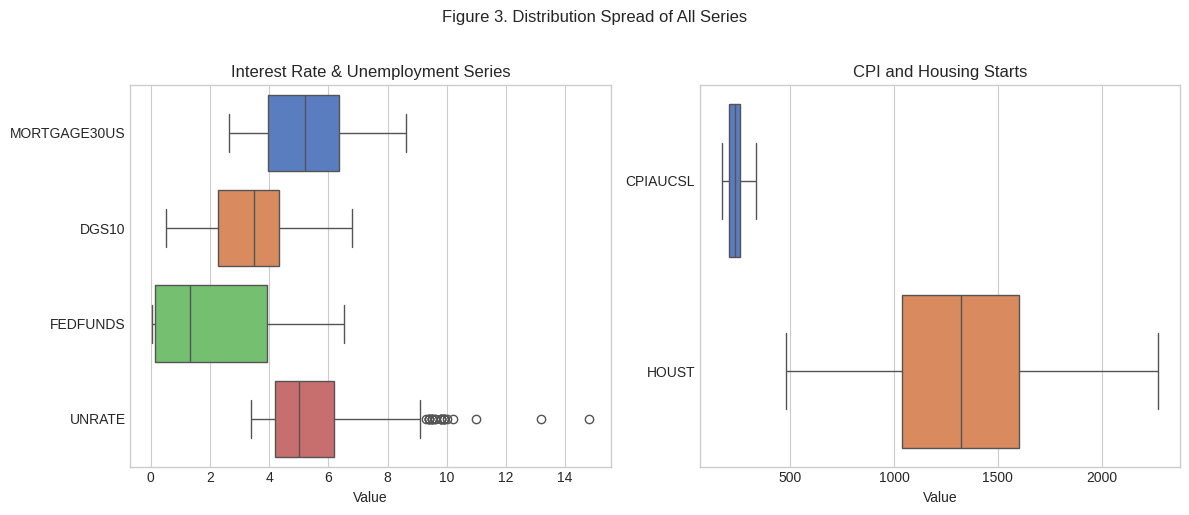

In [17]:
# Interest-rate series (similar scale)
rate_cols = ['MORTGAGE30US', 'DGS10', 'FEDFUNDS', 'UNRATE']
# Other series
other_cols = ['CPIAUCSL', 'HOUST']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df[rate_cols], orient='h', ax=axes[0])
axes[0].set_title("Interest Rate & Unemployment Series")
axes[0].set_xlabel("Value")

sns.boxplot(data=df[other_cols], orient='h', ax=axes[1])
axes[1].set_title("CPI and Housing Starts")
axes[1].set_xlabel("Value")

plt.suptitle("Figure 3. Distribution Spread of All Series", y=1.02)
plt.tight_layout()
plt.show()

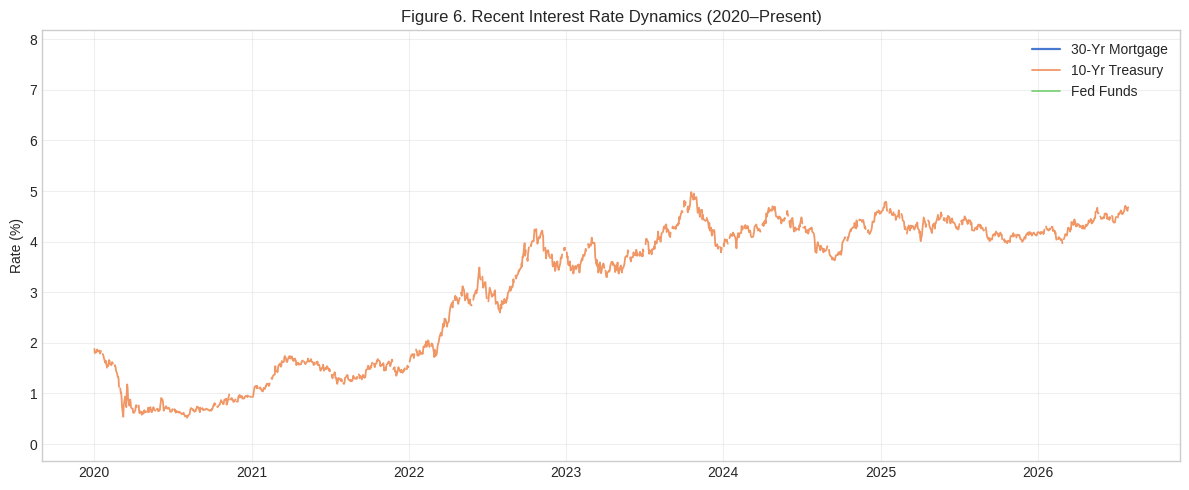

In [18]:
recent = df.loc['2020-01-01':]

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(recent.index, recent['MORTGAGE30US'], label='30-Yr Mortgage', linewidth=1.6)
ax.plot(recent.index, recent['DGS10'], label='10-Yr Treasury', linewidth=1.3, alpha=0.85)
ax.plot(recent.index, recent['FEDFUNDS'], label='Fed Funds', linewidth=1.3, alpha=0.85)

ax.set_title("Figure 6. Recent Interest Rate Dynamics (2020–Present)")
ax.set_ylabel("Rate (%)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

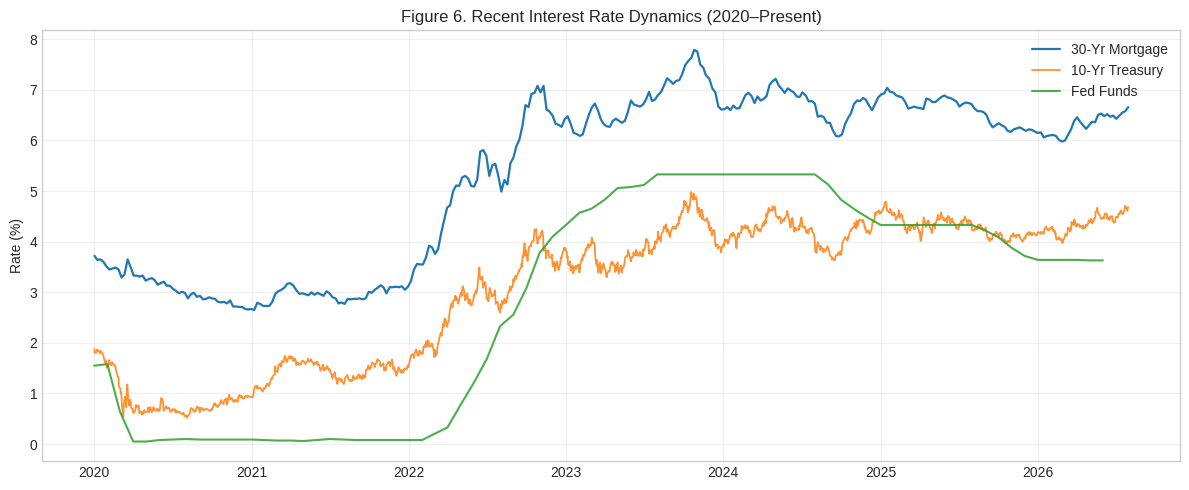

In [19]:
recent = df.loc['2020-01-01':]

fig, ax = plt.subplots(figsize=(12, 5))

# Plot each series after dropping its own NaNs
mort = recent['MORTGAGE30US'].dropna()
dgs  = recent['DGS10'].dropna()
fed  = recent['FEDFUNDS'].dropna()

ax.plot(mort.index, mort.values, label='30-Yr Mortgage', linewidth=1.6, color='#1f77b4')
ax.plot(dgs.index,  dgs.values,  label='10-Yr Treasury', linewidth=1.3, color='#ff7f0e', alpha=0.85)
ax.plot(fed.index,  fed.values,  label='Fed Funds',      linewidth=1.5, color='#2ca02c', alpha=0.85)

ax.set_title("Figure 6. Recent Interest Rate Dynamics (2020–Present)")
ax.set_ylabel("Rate (%)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

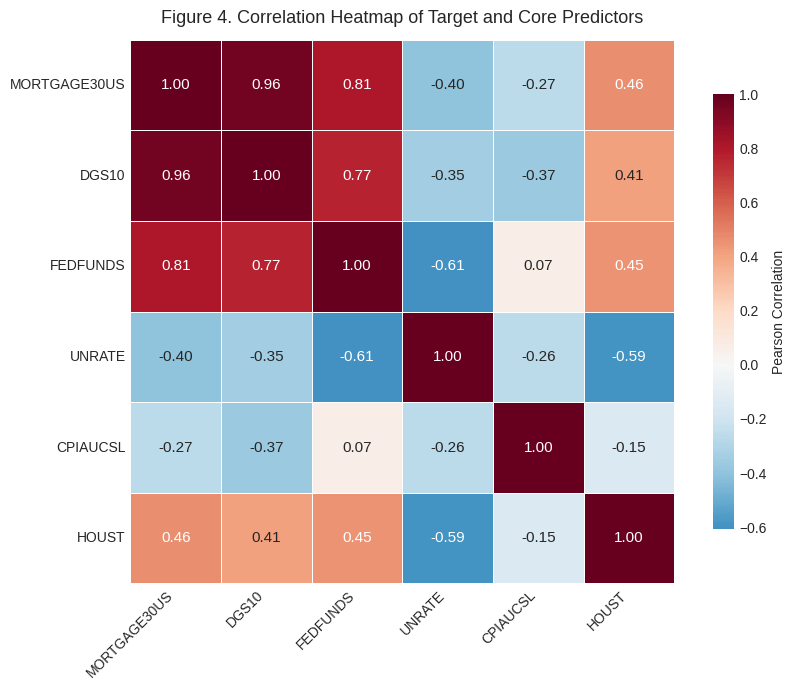

In [20]:
# Figure 4 – Correlation Heatmap
import matplotlib.pyplot as plt
import seaborn as sns

corr = df.corr(method='pearson')

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.6,
    cbar_kws={"shrink": 0.8, "label": "Pearson Correlation"},
    annot_kws={"size": 11}
)
plt.title("Figure 4. Correlation Heatmap of Target and Core Predictors", fontsize=13, pad=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()